## Рубежный контроль № 1
### Вариант 16 | Группа ИУ5-61Б | Нагдасёв Дмитрий
### Задача 2 | Набор данных: Boston housing dataset
1. Обработка пропусков для категориального и количественного признаков
2. Выбор признаков для построения моделей машинного обучения
3. Диаграмма рассеяния для пары признаков

## 1. Загрузка данных и первичный анализ

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета
df = pd.read_csv('/HousingData.csv')

print('Форма датасета:', df.shape)
print()
print('Первые 5 строк:')
df.head()

Форма датасета: (506, 14)

Первые 5 строк:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [20]:
print('Типы данных и количество непустых значений:')
df.info()

Типы данных и количество непустых значений:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [21]:
print('Количество пропущенных значений по столбцам:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропусков': missing, 'Доля (%)': missing_pct})
print(missing_df[missing_df['Пропусков'] > 0])

Количество пропущенных значений по столбцам:
       Пропусков  Доля (%)
CRIM          20      3.95
ZN            20      3.95
INDUS         20      3.95
CHAS          20      3.95
AGE           20      3.95
LSTAT         20      3.95


In [22]:
print('Описательная статистика:')
df.describe().round(3)

Описательная статистика:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000,486.000,486.000,486.000,506.000,506.000,486.000,506.000,506.000,506.000,506.000,506.000,486.000,506.000
mean,3.612,11.212,11.084,0.070,0.555,6.285,68.519,3.795,9.549,408.237,18.456,356.674,12.715,22.533
std,8.720,23.389,6.836,0.255,0.116,0.703,28.000,2.106,8.707,168.537,2.165,91.295,7.156,9.197
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.000,0.449,5.885,45.175,2.100,4.000,279.000,17.400,375.378,7.125,17.025
50%,0.254,0.000,9.690,0.000,0.538,6.208,76.800,3.207,5.000,330.000,19.050,391.440,11.430,21.200
75%,3.560,12.500,18.100,0.000,0.624,6.624,93.975,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.126,24.000,711.000,22.000,396.900,37.970,50.000


## 2. Создание категориального признака

В датасете все признаки числовые. Создадим категориальный признак **`PRICE_CATEGORY`** на основе целевой переменной `MEDV` (медианная стоимость дома):

- **`Low`** — MEDV < 17 (нижний квартиль)
- **`Medium`** — 17 ≤ MEDV < 25
- **`High`** — MEDV ≥ 25

In [23]:
# Создаём категориальный признак на основе MEDV
def categorize_price(val):
    if pd.isnull(val):
        return np.nan
    elif val < 17:
        return 'Low'
    elif val < 25:
        return 'Medium'
    else:
        return 'High'

df['PRICE_CATEGORY'] = df['MEDV'].apply(categorize_price)

print('Распределение категорий (до введения пропусков):')
print(df['PRICE_CATEGORY'].value_counts())
print()

# Искусственно вводим пропуски в категориальный признак (10% строк)
np.random.seed(42)
missing_idx = np.random.choice(df.index, size=int(0.10 * len(df)), replace=False)
df.loc[missing_idx, 'PRICE_CATEGORY'] = np.nan

print(f'Введено пропусков в PRICE_CATEGORY: {df["PRICE_CATEGORY"].isnull().sum()} ({df["PRICE_CATEGORY"].isnull().mean()*100:.1f}%)')
print('\nОбновлённое количество пропусков:')
print(df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT', 'PRICE_CATEGORY']].isnull().sum())

Распределение категорий (до введения пропусков):
PRICE_CATEGORY
Medium    248
High      132
Low       126
Name: count, dtype: int64

Введено пропусков в PRICE_CATEGORY: 50 (9.9%)

Обновлённое количество пропусков:
CRIM              20
ZN                20
INDUS             20
CHAS              20
AGE               20
LSTAT             20
PRICE_CATEGORY    50
dtype: int64


## 3. Обработка пропусков

### 3.1 Количественный признак: `LSTAT`

**`LSTAT`** — доля населения с низким социальным статусом (%). Это непрерывный количественный признак.

**Выбранный метод: заполнение медианой**

**Обоснование:** Медиана устойчива к выбросам (в отличие от среднего). Поскольку распределение `LSTAT` может быть правосторонним (длинный хвост у районов с высокой долей бедного населения), медиана является более репрезентативной мерой центральной тенденции и не искажается экстремальными значениями.

In [24]:
# Анализ распределения LSTAT
print('Статистика LSTAT (до обработки):')
print(f'  Пропусков:   {df["LSTAT"].isnull().sum()}')
print(f'  Среднее:     {df["LSTAT"].mean():.4f}')
print(f'  Медиана:     {df["LSTAT"].median():.4f}')
print(f'  Стд. откл.:  {df["LSTAT"].std():.4f}')
print(f'  Мин:         {df["LSTAT"].min():.4f}')
print(f'  Макс:        {df["LSTAT"].max():.4f}')
print(f'  Асимметрия:  {df["LSTAT"].skew():.4f} (>0 → правосторонний скос)')

# Заполнение медианой
lstat_median = df['LSTAT'].median()
df['LSTAT'] = df['LSTAT'].fillna(lstat_median)

print(f'\nПропуски в LSTAT после обработки: {df["LSTAT"].isnull().sum()}')
print(f'Использована медиана: {lstat_median:.4f}')

Статистика LSTAT (до обработки):
  Пропусков:   20
  Среднее:     12.7154
  Медиана:     11.4300
  Стд. откл.:  7.1559
  Мин:         1.7300
  Макс:        37.9700
  Асимметрия:  0.9089 (>0 → правосторонний скос)

Пропуски в LSTAT после обработки: 0
Использована медиана: 11.4300


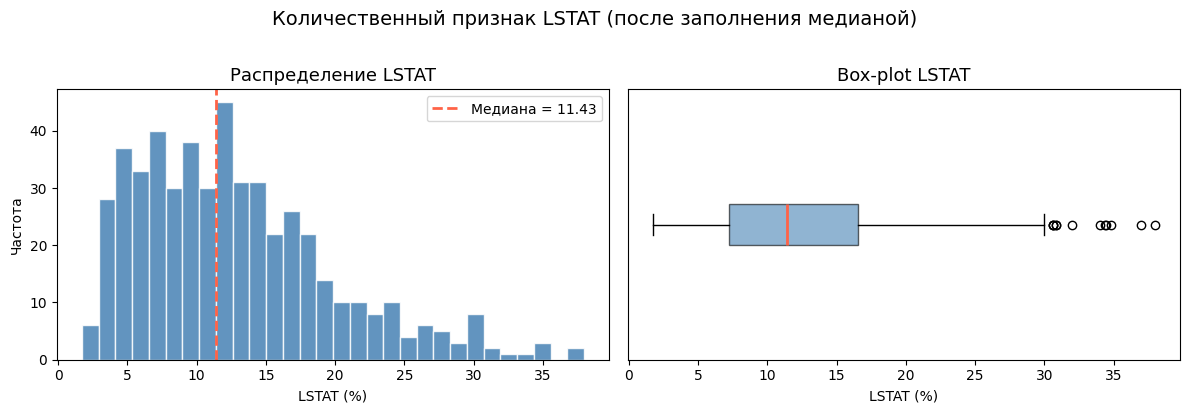

Вывод: Распределение LSTAT правостороннее (skew > 0), что подтверждает выбор медианы.


In [25]:
# Визуализация распределения LSTAT
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма
axes[0].hist(df['LSTAT'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(lstat_median, color='tomato', linestyle='--', linewidth=2, label=f'Медиана = {lstat_median:.2f}')
axes[0].set_title('Распределение LSTAT', fontsize=13)
axes[0].set_xlabel('LSTAT (%)')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Box plot
axes[1].boxplot(df['LSTAT'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Box-plot LSTAT', fontsize=13)
axes[1].set_xlabel('LSTAT (%)')
axes[1].set_yticks([])

plt.suptitle('Количественный признак LSTAT (после заполнения медианой)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Вывод: Распределение LSTAT правостороннее (skew > 0), что подтверждает выбор медианы.')

### 3.2 Категориальный признак: `PRICE_CATEGORY`

**Выбранный метод: заполнение модой (наиболее часто встречающейся категорией)**

**Обоснование:** Для категориальных признаков нельзя вычислить среднее или медиану. Мода — это единственная подходящая «центральная» характеристика для номинальных данных. Она сохраняет наиболее распространённую категорию и не искажает соотношение классов сильнее, чем другие методы (например, случайное присвоение категорий).

In [26]:
# Анализ PRICE_CATEGORY до обработки
print('Распределение PRICE_CATEGORY (до обработки):')
print(df['PRICE_CATEGORY'].value_counts(dropna=False))
print(f'\nПропусков: {df["PRICE_CATEGORY"].isnull().sum()}')

# Определяем моду
price_mode = df['PRICE_CATEGORY'].mode()[0]
print(f'Мода (наиболее частая категория): {price_mode}')

# Заполнение модой
df['PRICE_CATEGORY'] = df['PRICE_CATEGORY'].fillna(price_mode)

print(f'\nПропуски в PRICE_CATEGORY после обработки: {df["PRICE_CATEGORY"].isnull().sum()}')
print('\nРаспределение PRICE_CATEGORY (после обработки):')
print(df['PRICE_CATEGORY'].value_counts())

Распределение PRICE_CATEGORY (до обработки):
PRICE_CATEGORY
Medium    220
High      124
Low       112
NaN        50
Name: count, dtype: int64

Пропусков: 50
Мода (наиболее частая категория): Medium

Пропуски в PRICE_CATEGORY после обработки: 0

Распределение PRICE_CATEGORY (после обработки):
PRICE_CATEGORY
Medium    270
High      124
Low       112
Name: count, dtype: int64


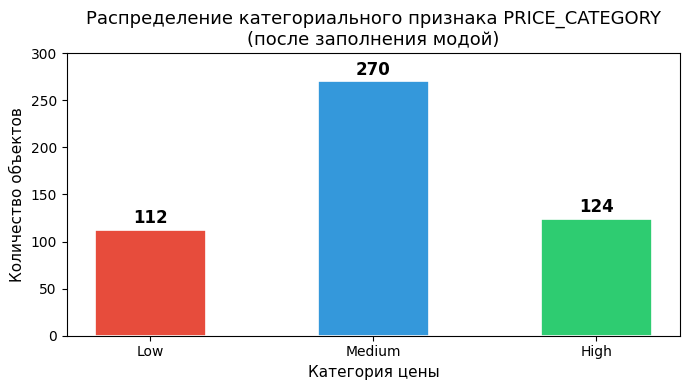

Пропуски заполнены модой: "Medium" — наиболее часто встречающаяся категория.


In [27]:
# Визуализация категориального признака
fig, ax = plt.subplots(figsize=(7, 4))

colors = {'Low': '#e74c3c', 'Medium': '#3498db', 'High': '#2ecc71'}
counts = df['PRICE_CATEGORY'].value_counts()
order = ['Low', 'Medium', 'High']
bar_colors = [colors[c] for c in order]

bars = ax.bar(order, [counts.get(c, 0) for c in order], color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)

for bar, cat in zip(bars, order):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Распределение категориального признака PRICE_CATEGORY\n(после заполнения модой)', fontsize=13)
ax.set_xlabel('Категория цены', fontsize=11)
ax.set_ylabel('Количество объектов', fontsize=11)
ax.set_ylim(0, counts.max() + 30)
plt.tight_layout()
plt.show()
print(f'Пропуски заполнены модой: "{price_mode}" — наиболее часто встречающаяся категория.')

## 4. Итоговая проверка пропусков

In [28]:
# Обрабатываем оставшиеся пропуски в числовых столбцах медианой
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print('Пропуски после всей обработки:')
total_missing = df.isnull().sum()
print(total_missing)
print(f'\nИтого пропусков в датасете: {total_missing.sum()}')

Пропуски после всей обработки:
CRIM              0
ZN                0
INDUS             0
CHAS              0
NOX               0
RM                0
AGE               0
DIS               0
RAD               0
TAX               0
PTRATIO           0
B                 0
LSTAT             0
MEDV              0
PRICE_CATEGORY    0
dtype: int64

Итого пропусков в датасете: 0


## 5. Выбор признаков для построения моделей МО

Проведём корреляционный анализ, чтобы обоснованно выбрать признаки.

In [29]:
# Корреляция числовых признаков с целевой переменной MEDV
corr_with_target = df[numeric_cols].corr()['MEDV'].drop('MEDV').sort_values()
print('Корреляция признаков с MEDV (целевая переменная):')
print(corr_with_target.round(3))

Корреляция признаков с MEDV (целевая переменная):
LSTAT     -0.723
PTRATIO   -0.508
INDUS     -0.476
TAX       -0.469
NOX       -0.427
CRIM      -0.384
RAD       -0.382
AGE       -0.378
CHAS       0.184
DIS        0.250
B          0.333
ZN         0.362
RM         0.695
Name: MEDV, dtype: float64


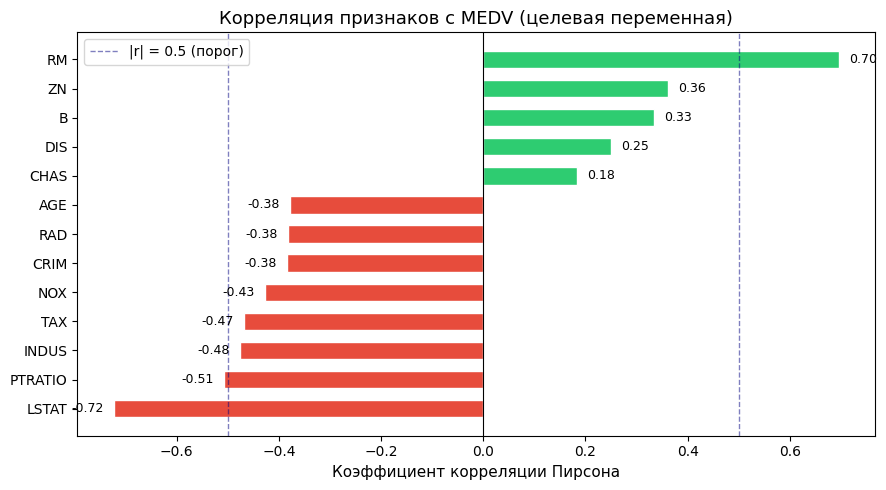

In [30]:
# Визуализация корреляций
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=bar_colors, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.5, color='navy', linewidth=1, linestyle='--', alpha=0.5, label='|r| = 0.5 (порог)')
ax.axvline(-0.5, color='navy', linewidth=1, linestyle='--', alpha=0.5)

for bar, val in zip(bars, corr_with_target.values):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_title('Корреляция признаков с MEDV (целевая переменная)', fontsize=13)
ax.set_xlabel('Коэффициент корреляции Пирсона', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# Выбранные признаки
selected_features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'AGE']
target = 'MEDV'

print('=' * 60)
print('ВЫБРАННЫЕ ПРИЗНАКИ ДЛЯ МОДЕЛЕЙ МО:')
print('=' * 60)

descriptions = {
    'RM':      ('Среднее кол-во комнат',        '+0.70', 'Сильная положительная корреляция с ценой'),
    'LSTAT':   ('Доля населения с низким статусом', '-0.72', 'Сильная отрицательная корреляция с ценой'),
    'PTRATIO': ('Соотношение учеников и учителей', '-0.51', 'Умеренная отрицательная корреляция'),
    'INDUS':   ('Доля нежилой территории',       '-0.48', 'Умеренная отрицательная корреляция'),
    'TAX':     ('Ставка налога на имущество',    '-0.47', 'Умеренная отрицательная корреляция'),
    'NOX':     ('Концентрация оксидов азота',    '-0.43', 'Связан с промзонами и трафиком'),
    'CRIM':    ('Уровень преступности',          '-0.38', 'Важный социальный фактор'),
    'AGE':     ('Доля старых домов',             '-0.38', 'Характеризует возраст застройки'),
}

print(f'  {"Признак":<10} {"Описание":<38} {"r с MEDV":<12} {"Обоснование"}')
print('  ' + '-' * 95)
for feat in selected_features:
    desc, corr, reason = descriptions[feat]
    print(f'  {feat:<10} {desc:<38} {corr:<12} {reason}')

print()
print('Исключены признаки:')
excluded = {
    'ZN':  'Слабая корреляция с MEDV (r=+0.36), малоинформативен',
    'DIS': 'Коллинеарен с NOX и INDUS',
    'RAD': 'Слабая корреляция (r=-0.38), дублирует TAX',
    'B':   'Специфичный социальный признак, слабая корреляция',
    'CHAS': 'Бинарный (река рядом?), очень слабая корреляция (r=+0.18)',
}
for feat, reason in excluded.items():
    print(f'  {feat:<10} {reason}')
print()
print(f'Целевая переменная: {target} (медианная стоимость дома, тыс. долл.)')

ВЫБРАННЫЕ ПРИЗНАКИ ДЛЯ МОДЕЛЕЙ МО:
  Признак    Описание                               r с MEDV     Обоснование
  -----------------------------------------------------------------------------------------------
  RM         Среднее кол-во комнат                  +0.70        Сильная положительная корреляция с ценой
  LSTAT      Доля населения с низким статусом       -0.72        Сильная отрицательная корреляция с ценой
  PTRATIO    Соотношение учеников и учителей        -0.51        Умеренная отрицательная корреляция
  INDUS      Доля нежилой территории                -0.48        Умеренная отрицательная корреляция
  TAX        Ставка налога на имущество             -0.47        Умеренная отрицательная корреляция
  NOX        Концентрация оксидов азота             -0.43        Связан с промзонами и трафиком
  CRIM       Уровень преступности                   -0.38        Важный социальный фактор
  AGE        Доля старых домов                      -0.38        Характеризует возраст застр

## 6. Диаграмма рассеяния

Построим диаграмму рассеяния для пары **`RM`** (среднее количество комнат) и **`MEDV`** (медианная стоимость дома) — это два признака с наибольшей корреляцией по модулю. Точки окрашены по категории `PRICE_CATEGORY`.

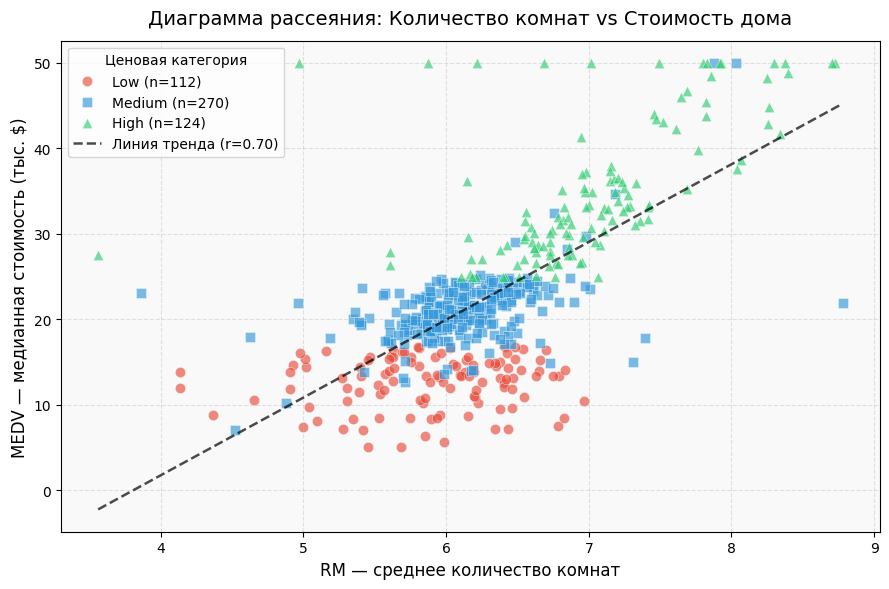

Коэффициент корреляции Пирсона между RM и MEDV: 0.6954
Вывод: прослеживается чёткая положительная линейная зависимость.
Дома категории High (зелёные ▲) концентрируются при RM > 6.5 и MEDV > 25 тыс. $


In [32]:
fig, ax = plt.subplots(figsize=(9, 6))

color_map = {'Low': '#e74c3c', 'Medium': '#3498db', 'High': '#2ecc71'}
marker_map = {'Low': 'o', 'Medium': 's', 'High': '^'}

for category in ['Low', 'Medium', 'High']:
    mask = df['PRICE_CATEGORY'] == category
    ax.scatter(
        df.loc[mask, 'RM'],
        df.loc[mask, 'MEDV'],
        c=color_map[category],
        marker=marker_map[category],
        alpha=0.65,
        s=55,
        edgecolors='white',
        linewidths=0.4,
        label=f'{category} (n={mask.sum()})'
    )

# Линия тренда
z = np.polyfit(df['RM'], df['MEDV'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['RM'].min(), df['RM'].max(), 200)
ax.plot(x_line, p(x_line), 'k--', linewidth=1.8, alpha=0.7, label=f'Линия тренда (r={df["RM"].corr(df["MEDV"]):.2f})')

ax.set_title('Диаграмма рассеяния: Количество комнат vs Стоимость дома', fontsize=14, pad=12)
ax.set_xlabel('RM — среднее количество комнат', fontsize=12)
ax.set_ylabel('MEDV — медианная стоимость (тыс. $)', fontsize=12)
ax.legend(title='Ценовая категория', fontsize=10, title_fontsize=10)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

print(f'Коэффициент корреляции Пирсона между RM и MEDV: {df["RM"].corr(df["MEDV"]):.4f}')
print('Вывод: прослеживается чёткая положительная линейная зависимость.')
print('Дома категории High (зелёные ▲) концентрируются при RM > 6.5 и MEDV > 25 тыс. $')

## 7. Итоговое резюме

### Методы обработки пропусков

| Тип признака | Признак | Метод | Обоснование |
|---|---|---|---|
| **Количественный** | `LSTAT` | Заполнение **медианой** | Медиана устойчива к выбросам; LSTAT имеет правостороннее распределение (skew > 0), поэтому среднее было бы смещено |
| **Категориальный** | `PRICE_CATEGORY` | Заполнение **модой** | Для номинальных данных нельзя вычислить среднее; мода — единственная корректная «центральная» характеристика |

### Признаки для моделей МО

Выбраны 8 признаков с наибольшей корреляцией с целевой переменной `MEDV`:
- **RM, LSTAT** — наиболее сильные предикторы (|r| > 0.70)
- **PTRATIO, INDUS, TAX** — умеренная корреляция (|r| ≈ 0.45–0.52)
- **NOX, CRIM, AGE** — дополнительные информативные признаки

Эти признаки охватывают ключевые факторы стоимости: **размер жилья, социальную среду, инфраструктуру, экологию и уровень преступности**.